In [22]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
from sklearn.model_selection import train_test_split;

In [23]:
# 1. Define data
dummy_data = np.array([[4, 5], [4, -5], [-4, -5], [-4, 5]])

In [24]:
a,b,c = 1,1,-2;
alpha = 0.01;
x = np.linspace(-4,+4,100);
y = (-a/b)*x + (-c/b);

   x  y  label
0  4  5     -1
1  4 -5     -1
2 -4 -5      1
3 -4  5     -1


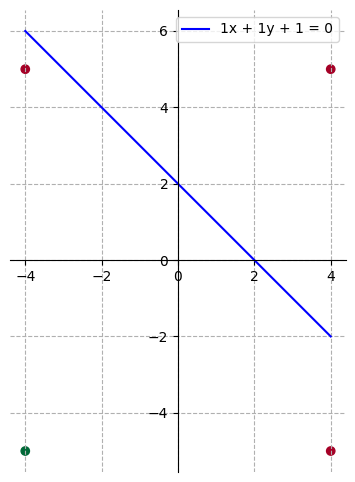

In [25]:
# Pandafication
df=pd.DataFrame(dummy_data, columns=["x","y"]);
# Labelisation
df["label"] = np.where((df["x"]<0) & (df["y"]<0), +1,-1);
print(df);

# Beautification
fig,ax = plt.subplots(figsize=(6,6));

scatter = ax.scatter(df["x"],df["y"], c=df["label"], cmap="RdYlGn");
# Optional: adds a legend

# Grid Fixing
ax.spines['left'].set_position('zero');
ax.spines['bottom'].set_position('zero');
ax.spines['right'].set_color('none');
ax.spines['top'].set_color('none');
ax.grid(True,linestyle="--");
ax.set_aspect('equal');

ax.plot(x, y, color='blue', label='1x + 1y + 1 = 0');
ax.legend();
plt.show();

   x  y  label
0  4  5     -1
1  4 -5     -1
2 -4 -5      1
3 -4  5     -1


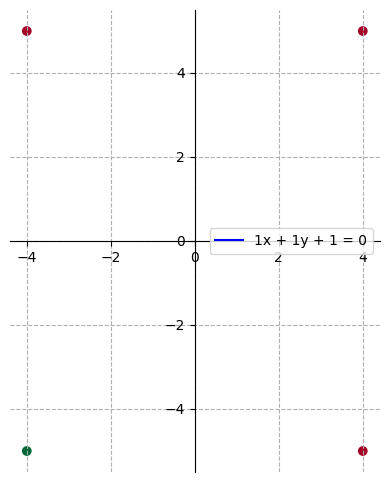

In [26]:

# 1. Define data
dummy_data = np.array([[4, 5], [4, -5], [-4, -5], [-4, 5]])
a,b,c = 1,1,-2;
alpha = 1;
x = np.linspace(-4,+4,100);
y = (-a/b)*x + (-c/b);
# Perceptron Trick Algorithm

# Pandafication
df=pd.DataFrame(dummy_data, columns=["x","y"]);
# Labelisation
df["label"] = np.where((df["x"]<0) & (df["y"]<0), +1,-1);
print(df);

# Beautification
fig,ax = plt.subplots(figsize=(6,6));

scatter = ax.scatter(df["x"],df["y"], c=df["label"], cmap="RdYlGn");
# Optional: adds a legend

# Grid Fixing
ax.spines['left'].set_position('zero');
ax.spines['bottom'].set_position('zero');
ax.spines['right'].set_color('none');
ax.spines['top'].set_color('none');
ax.grid(True,linestyle="--");
ax.set_aspect('equal');

for i in range(10):
    r = np.random.randint(0,4);
    x,y,l = df.iloc[r];
    calculated_label = 1 if (a*x + b*y + c) < 0 else -1;
    if calculated_label == l:
        pass;
    else:
        if l==-1:
            a = a-x;
            b = b-x;
            c = c-(l**2);
    ax.plot(x, y, color='blue', label='1x + 1y + 1 = 0');
    ax.legend();
    plt.show();
    



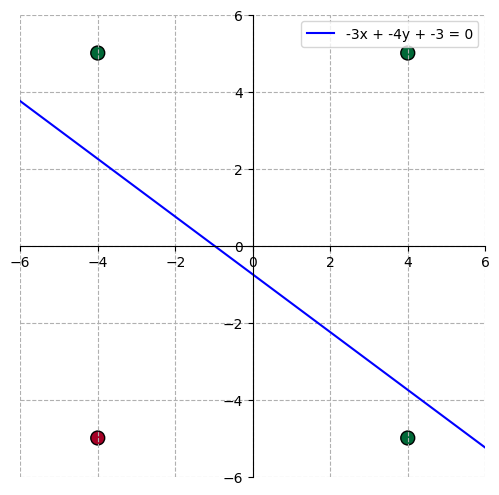

In [28]:
from IPython.display import display, clear_output
import time

# 1. Define data & Setup
dummy_data = np.array([[4, 5], [4, -5], [-4, -5], [-4, 5]]);
df = pd.DataFrame(dummy_data, columns=["x","y"]);
df["label"] = np.where((df["x"]<0) & (df["y"]<0), -1, +1);

a, b, c = 1, 1, -2;
x_range = np.linspace(-6, 6, 10000); # Renamed to x_range to avoid confusion

# 2. Run Loop
for i in range(10):
    # Pick random point
    r = np.random.randint(0, 4);
    rx, ry, l = df.iloc[r];  # CHANGED: x,y -> rx,ry to not overwrite x_range

    # Calculate current prediction
    calculated_label = 1 if (a*rx + b*ry + c) < 0 else -1;
    
    # Update weights if wrong
    if calculated_label != l:
        if l == -1:
            a = a + alpha*rx;
            b = b + alpha*ry;
            c = c + alpha*1;
        elif l == 1:
            a = a - alpha*rx;
            b = b - alpha*ry;
            c = c - alpha*1;

    # --- PLOTTING BLOCK (Moved inside loop) ---
    clear_output(wait=True); # Clears the previous frame
    fig, ax = plt.subplots(figsize=(6,6));
    
    # Draw Scatter
    ax.scatter(df["x"], df["y"], c=df["label"], cmap="RdYlGn", s=100, edgecolors='k');
    
    # Draw Line (Recalculate y with NEW a,b,c)
    y_range = (-a/b)*x_range - (c/b); 
    ax.plot(x_range, y_range, color='blue', label=f'{a}x + {b}y + {c} = 0');
    
    # Fix Grid
    ax.spines['left'].set_position('zero');
    ax.spines['bottom'].set_position('zero');
    ax.spines['right'].set_color('none');
    ax.spines['top'].set_color('none');
    ax.grid(True, linestyle="--");
    ax.set_xlim(-6, 6);
    ax.set_ylim(-6, 6);
    ax.legend(loc='upper right');
    
    plt.show();
    time.sleep(0.5); # Pause to see the animation